# 🌿 Leaf Disease Classification — Custom CNN From Scratch (1 Fase)
**Dataset:** 72 Kelas — `train/` + `val/` + `test/`
**Model:** CNN custom, dibangun dari nol (TANPA transfer learning / TANPA pretrained weights)
**Training:** 1 Fase saja — seluruh layer dilatih bersamaan dari awal (tidak ada freeze/fine-tune bertahap)

> **Perbedaan dari versi PreTained:**
> - ❌ Tidak memakai PreTained weights
> - ✅ Arsitektur CNN custom: 5 blok Conv (32→64→128→256→512) + BatchNorm + MaxPooling + Dropout bertingkat
> - ✅ Preprocessing: rescale sederhana `[0,1]` (bukan `preprocess_input` InceptionV3)
> - ✅ **1 Fase training** — tidak ada Fase 1 (freeze) & Fase 2 (fine-tune), karena tidak ada backbone pretrained yang perlu dibekukan
> - ✅ LR lebih tinggi & warmup+cosine decay karena training from scratch butuh eksplorasi lebih besar
> - ✅ Class weight, augmentasi on-the-fly, Grad-CAM, t-SNE tetap dipertahankan agar alur analisis sama seperti versi PreTained


In [1]:
import os, json, random, glob, math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2

from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.preprocessing import image

print("TensorFlow :", tf.__version__)
print("Keras      :", tf.keras.__version__)


c:\Users\crism\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


TensorFlow : 2.10.1
Keras      : 2.10.0


## 1. Konfigurasi GPU (CUDA)

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    tf.config.set_visible_devices(gpus[0], 'GPU')
    print(f"✅ GPU: {gpus[0].name}")
else:
    print("⚠️  CPU mode")

print("Logical devices:", tf.config.list_logical_devices())
print("CUDA built     :", tf.test.is_built_with_cuda())


✅ GPU: /physical_device:GPU:0
Logical devices: [LogicalDevice(name='/device:CPU:0', device_type='CPU'), LogicalDevice(name='/device:GPU:0', device_type='GPU')]
CUDA built     : True


## 2. Konfigurasi Path & Parameter

In [3]:
BASE_PATH  = r"C:\Users\crism\Music\80 10 10"
SAVE_DIR   = r"C:\Users\crism\Music\New folder (5)\final_output\8\(8) Custom CNN  811"
SAVE_MODEL = os.path.join(SAVE_DIR, "models")
SAVE_LABEL = os.path.join(SAVE_DIR, "labels")
os.makedirs(SAVE_MODEL, exist_ok=True)
os.makedirs(SAVE_LABEL, exist_ok=True)

TRAIN_DIR = os.path.join(BASE_PATH, "train")
VALID_DIR = os.path.join(BASE_PATH, "val")
TEST_DIR  = os.path.join(BASE_PATH, "test")

IMG_SIZE   = (256, 256)
IMG_SHAPE  = (256, 256, 3)
NUM_CLASSES = 72

BATCH_SIZE = 8
AUTOTUNE   = tf.data.AUTOTUNE

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"BATCH_SIZE : {BATCH_SIZE}")
print(f"IMG_SIZE   : {IMG_SIZE}")
for name, path in [("train", TRAIN_DIR), ("valid", VALID_DIR), ("test", TEST_DIR)]:
    ok = "✅" if os.path.isdir(path) else "❌"
    print(f"  {ok} {name}: {path}")


BATCH_SIZE : 8
IMG_SIZE   : (256, 256)
  ✅ train: C:\Users\crism\Music\80 10 10\train
  ✅ valid: C:\Users\crism\Music\80 10 10\val
  ✅ test: C:\Users\crism\Music\80 10 10\test


## 2a. Preview Dataset — Gambar Asli (Belum Augmentasi)
> 8 gambar acak langsung dari disk, dibaca dengan `cv2` — belum disentuh preprocessing apapun.

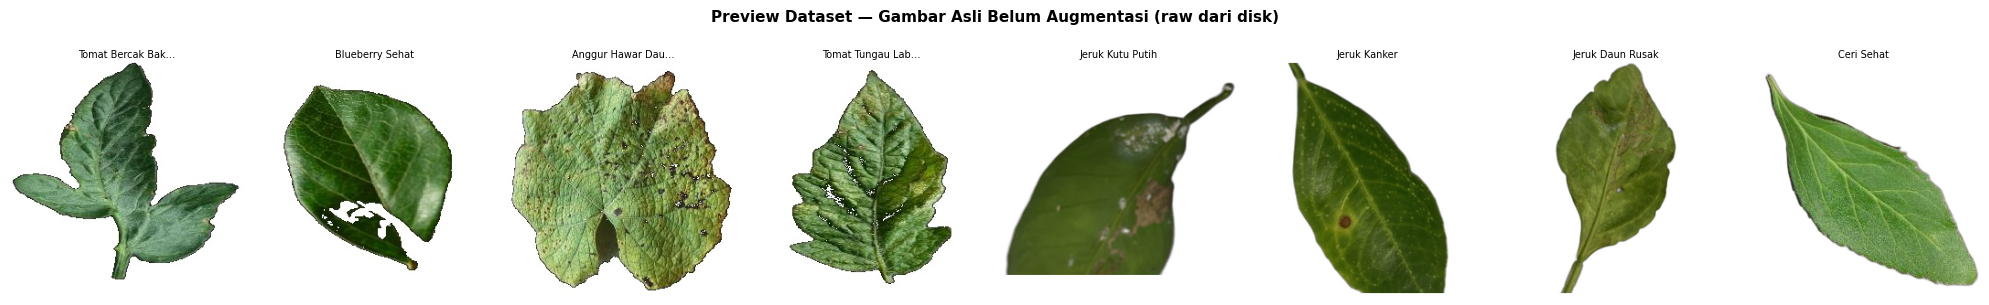

✅ Raw preview disimpan: C:\Users\crism\Music\New folder (5)\final_output\8\(8) Custom CNN  811\raw_preview.png


In [4]:
N_RAW = 8

raw_all_paths = []
for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG'):
        raw_all_paths.extend(glob.glob(os.path.join(cls_dir, ext)))

random.seed(SEED)
raw_sample = random.sample(raw_all_paths, N_RAW)

fig, axes = plt.subplots(1, N_RAW, figsize=(N_RAW * 2.5, 3.2))
fig.suptitle('Preview Dataset — Gambar Asli Belum Augmentasi (raw dari disk)',
             fontsize=11, fontweight='bold')

for i, path in enumerate(raw_sample):
    class_name = os.path.basename(os.path.dirname(path))
    short_name = class_name[:16] + '…' if len(class_name) > 16 else class_name

    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)

    axes[i].imshow(img)
    axes[i].set_title(short_name, fontsize=7, pad=3)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'raw_preview.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ Raw preview disimpan: {os.path.join(SAVE_DIR, 'raw_preview.png')}")


## 3. tf.data Pipeline
> Augmentasi on-the-fly **diaktifkan** untuk train. Val & test **tidak diaugmentasi**.
> **Preprocessing custom CNN:** cukup rescale piksel `[0,255] → [0,1]` (bukan `preprocess_input` InceptionV3 yang menghasilkan `[-1,1]`), karena model dilatih dari nol dan tidak butuh statistik normalisasi ImageNet.

In [5]:
rotation_layer = tf.keras.layers.RandomRotation(
    factor=0.1,           # ±36 derajat  (0.1 × 360°)
    fill_mode="reflect",
    seed=SEED
)

def load_image(path, label):
    """Baca gambar dari disk → float32 [0,255], resize ke IMG_SIZE."""
    raw   = tf.io.read_file(path)
    image = tf.image.decode_jpeg(raw, channels=3)
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, IMG_SIZE)
    return image, label

def rescale(image):
    """[0,255] -> [0,1] — preprocessing sederhana untuk CNN from scratch."""
    return image / 255.0

@tf.function
def augment_train(image, label):
    """
    Augmentasi on-the-fly.
    Input  : float32 [0,255]
    Output : rescale [0,1]
    """
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.2 * 255)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.7, upper=1.3)
    image = tf.image.random_hue(image, max_delta=0.05)

    crop_frac = tf.random.uniform([], 0.85, 1.0)
    crop_h    = tf.cast(tf.cast(IMG_SIZE[0], tf.float32) * crop_frac, tf.int32)
    crop_w    = tf.cast(tf.cast(IMG_SIZE[1], tf.float32) * crop_frac, tf.int32)
    image     = tf.image.random_crop(image, size=[crop_h, crop_w, 3])
    image     = tf.image.resize(image, IMG_SIZE)

    image = rotation_layer(tf.expand_dims(image, 0), training=True)[0]

    image = tf.clip_by_value(image, 0., 255.)
    image = rescale(image)
    return image, label

@tf.function
def preprocess_eval(image, label):
    image = rescale(image)
    return image, label

def one_hot(image, label):
    return image, tf.one_hot(label, NUM_CLASSES)

_raw_train = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=None, shuffle=True,
    seed=SEED, label_mode="int"
)
class_names   = _raw_train.class_names
class_indices = {name: i for i, name in enumerate(class_names)}
print(f"Jumlah kelas terdeteksi: {len(class_names)}")
assert len(class_names) == NUM_CLASSES, \
    f"Kelas terdeteksi {len(class_names)} ≠ NUM_CLASSES={NUM_CLASSES}"

train_labels = []
for _, lbl in _raw_train:
    train_labels.append(lbl.numpy())
train_labels = np.array(train_labels)
print(f"Total sampel train : {len(train_labels)}")

train_ds = (
    _raw_train
    .map(lambda img, lbl: (tf.cast(img, tf.float32), lbl), num_parallel_calls=AUTOTUNE)
    .map(augment_train, num_parallel_calls=AUTOTUNE)
    .map(one_hot,       num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

_raw_valid = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR, image_size=IMG_SIZE, batch_size=None, shuffle=False,
    seed=SEED, label_mode="int"
)
valid_ds = (
    _raw_valid
    .map(lambda img, lbl: (tf.cast(img, tf.float32), lbl), num_parallel_calls=AUTOTUNE)
    .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
    .map(one_hot,         num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

_raw_test = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=None, shuffle=False,
    seed=SEED, label_mode="int"
)
test_ds = (
    _raw_test
    .map(lambda img, lbl: (tf.cast(img, tf.float32), lbl), num_parallel_calls=AUTOTUNE)
    .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
    .map(one_hot,         num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("\n✅ Semua pipeline siap.")
print(f"  train_ds : {train_ds}")
print(f"  valid_ds : {valid_ds}")
print(f"  test_ds  : {test_ds}")


Found 57682 files belonging to 72 classes.
Jumlah kelas terdeteksi: 72
Total sampel train : 57682
Found 7158 files belonging to 72 classes.
Found 7160 files belonging to 72 classes.

✅ Semua pipeline siap.
  train_ds : <PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 72), dtype=tf.float32, name=None))>
  valid_ds : <PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 72), dtype=tf.float32, name=None))>
  test_ds  : <PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 72), dtype=tf.float32, name=None))>


## 4. Visualisasi Augmentasi — Sebelum vs Sesudah
> **Sebelum:** gambar raw setelah `load_image` (pixel [0,255])
> **Sesudah:** gambar setelah `augment_train` (rescale [0,1]), dikalikan kembali 255 untuk ditampilkan

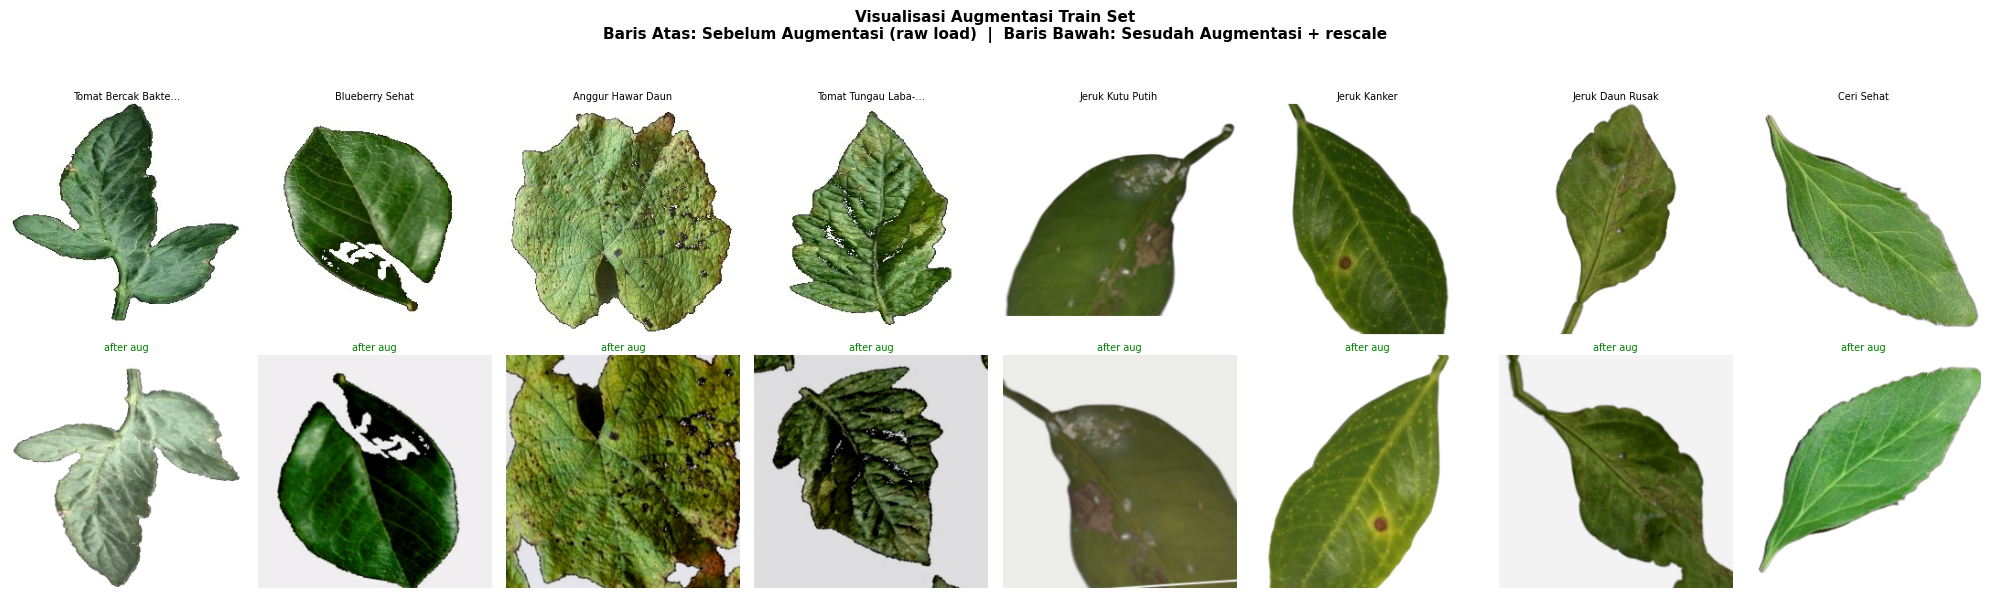

✅ Preview disimpan: C:\Users\crism\Music\New folder (5)\final_output\8\(8) Custom CNN  811\augmentation_preview.png


In [6]:
N_VIS = 8

all_train_paths = []
for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG'):
        all_train_paths.extend(glob.glob(os.path.join(cls_dir, ext)))

random.seed(SEED)
sample_paths = random.sample(all_train_paths, N_VIS)

def denormalize_rescale(img_tensor):
    """Balik rescale [0,1] -> [0,255] untuk ditampilkan."""
    img = img_tensor.numpy() if hasattr(img_tensor, 'numpy') else img_tensor
    img = img * 255.0
    return np.clip(img, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(2, N_VIS, figsize=(N_VIS * 2.5, 6))
fig.suptitle('Visualisasi Augmentasi Train Set\n'
             'Baris Atas: Sebelum Augmentasi (raw load)  |  '
             'Baris Bawah: Sesudah Augmentasi + rescale',
             fontsize=11, fontweight='bold', y=1.02)

for i, path in enumerate(sample_paths):
    class_name = os.path.basename(os.path.dirname(path))
    short_name = class_name[:18] + '…' if len(class_name) > 18 else class_name

    dummy_label = tf.zeros(NUM_CLASSES)
    img_raw, _ = load_image(path, dummy_label)
    img_before = img_raw.numpy().astype(np.uint8)

    img_aug, _ = augment_train(img_raw, dummy_label)
    img_after  = denormalize_rescale(img_aug)

    axes[0, i].imshow(img_before)
    axes[0, i].set_title(f'{short_name}', fontsize=7, pad=3)
    axes[0, i].axis('off')

    axes[1, i].imshow(img_after)
    axes[1, i].set_title('after aug', fontsize=7, pad=3, color='green')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Sebelum\n(raw load)', fontsize=9, color='steelblue',
                       rotation=90, labelpad=5)
axes[1, 0].set_ylabel('Sesudah\n(aug+rescale)', fontsize=9, color='green',
                       rotation=90, labelpad=5)
for ax in axes.flat:
    ax.set_visible(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'augmentation_preview.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ Preview disimpan: {os.path.join(SAVE_DIR, 'augmentation_preview.png')}")


## 5. Class Weights (Imbalance Handling)

In [7]:
unique_labels = np.unique(train_labels)
calc_weights  = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_labels,
    y=train_labels
)
class_weights_dict = {int(k): float(min(v, 5.0)) for k, v in zip(unique_labels, calc_weights)}
print(f"Class weights ({len(class_weights_dict)} kelas) — clipped at 5.0")
w_vals = list(class_weights_dict.values())
print(f"  min={min(w_vals):.4f} | max={max(w_vals):.4f} | mean={np.mean(w_vals):.4f}")


Class weights (72 kelas) — clipped at 5.0
  min=0.9083 | max=1.0014 | mean=1.0001


## 6. Arsitektur Model — Custom CNN From Scratch (1 Fase)
> **Tanpa pretrained weights.** Arsitektur dibangun manual: 5 blok Convolutional dengan filter membesar
> (32 → 64 → 128 → 256 → 512), tiap blok berisi 2×(Conv2D → BatchNorm → ReLU) lalu MaxPooling + Dropout
> bertingkat (semakin dalam, semakin besar dropout-nya) untuk anti-overfitting.
>
> **Kenapa hanya 1 fase?**
> Karena tidak ada backbone pretrained yang perlu dibekukan lalu di-fine-tune, seluruh bobot model
> dilatih bersamaan dari epoch pertama sampai selesai — cukup 1 fase training saja.

In [8]:
strategy = tf.distribute.MirroredStrategy()
print(f"Jumlah device: {strategy.num_replicas_in_sync}")

try:
    from tensorflow.keras.optimizers.experimental import AdamW
    optimizer = AdamW(learning_rate=1e-3, weight_decay=1e-4)
    print("Optimizer : AdamW (experimental)")
except Exception:
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    print("Optimizer : Adam")


def conv_block(x, filters, block_id, dropout_rate, last_conv_name=None):
    conv_name = f"block{block_id}_conv2" if last_conv_name is None else last_conv_name
    x = layers.Conv2D(filters, 3, padding="same",
                       kernel_regularizer=regularizers.l2(1e-5),
                       name=f"block{block_id}_conv1")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same",
                       kernel_regularizer=regularizers.l2(1e-5),
                       name=conv_name)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)
    return x


with strategy.scope():

    def build_model(num_classes, input_shape):
        inputs = layers.Input(shape=input_shape, name="input_image")

        x = conv_block(inputs, 32,  block_id=1, dropout_rate=0.10)
        x = conv_block(x,      64,  block_id=2, dropout_rate=0.15)
        x = conv_block(x,      128, block_id=3, dropout_rate=0.20)
        x = conv_block(x,      256, block_id=4, dropout_rate=0.25)
        x = conv_block(x,      512, block_id=5, dropout_rate=0.30,
                        last_conv_name="last_conv")   # <- dipakai Grad-CAM

        x = layers.GlobalAveragePooling2D()(x)
        x = layers.BatchNormalization()(x)

        x = layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=regularizers.l2(1e-5),
            name="feature_dense"
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.40)(x)

        outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

        return models.Model(inputs, outputs, name="custom_cnn_scratch")

    model = build_model(NUM_CLASSES, IMG_SHAPE)

    loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)

    model.compile(
        optimizer=optimizer,
        loss=loss_fn,
        metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy")]
    )

trainable = np.sum([np.prod(v.shape) for v in model.trainable_weights])
nontrainable = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])

print("=" * 60)
print(f"Total trainable params     : {trainable:,}")
print(f"Total non-trainable params : {nontrainable:,}")
print("=" * 60)

model.summary()


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
Jumlah device: 1
Optimizer : AdamW (experimental)
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:ten

## 7. Cosine Annealing LR dengan Warmup
> Karena training murni from scratch (bukan fine-tuning), peak LR dibuat lebih tinggi (`1e-3`)
> dibanding versi transfer learning, dengan warmup 5 epoch agar training stabil di awal.

In [9]:
class WarmupCosineDecay(callbacks.Callback):
    """LR naik linear saat warmup, lalu turun cosine hingga min_lr."""
    def __init__(self, total_epochs, warmup_epochs=5,
                 start_lr=1e-5, peak_lr=1e-3, min_lr=1e-6):
        super().__init__()
        self.total_epochs  = total_epochs
        self.warmup_epochs = warmup_epochs
        self.start_lr      = start_lr
        self.peak_lr       = peak_lr
        self.min_lr        = min_lr

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.start_lr + (self.peak_lr - self.start_lr) * (epoch / self.warmup_epochs)
        else:
            progress = (epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + 0.5 * (self.peak_lr - self.min_lr) * (
                1 + math.cos(math.pi * progress))
        tf.keras.backend.set_value(self.model.optimizer.learning_rate, lr)
        print(f"  [LR] Epoch {epoch+1}: lr = {lr:.2e}")

print("WarmupCosineDecay callback siap.")


WarmupCosineDecay callback siap.


## 8. Callbacks (1 Fase)

In [10]:
EPOCHS = 80  # from-scratch butuh epoch lebih banyak dibanding transfer learning

cb_single = [
    WarmupCosineDecay(
        total_epochs=EPOCHS,
        warmup_epochs=5,
        start_lr=1e-5,
        peak_lr=1e-3,
        min_lr=1e-6
    ),
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        os.path.join(SAVE_MODEL, "custom_cnn_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks siap.")
print(f"  Training: max {EPOCHS} epoch, LR peak 1e-3, warmup 5 epoch")


Callbacks siap.
  Training: max 80 epoch, LR peak 1e-3, warmup 5 epoch


## 9. Training — 1 Fase (Seluruh Layer Dilatih Bersamaan)
> Tidak ada backbone yang dibekukan, sehingga seluruh bobot (convolution blocks + head) dilatih
> sejak epoch pertama.

In [11]:
print("=" * 60)
print("TRAINING — CUSTOM CNN FROM SCRATCH (1 FASE)")
print("=" * 60)

if tf.config.list_physical_devices('GPU'):
    print(f"✅ GPU: {tf.config.list_physical_devices('GPU')[0].name}")

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=cb_single,
    class_weight=class_weights_dict
)

model.save(os.path.join(SAVE_MODEL, "custom_cnn_last.keras"))
print("✓ Model terakhir disimpan: custom_cnn_last.keras")


TRAINING — CUSTOM CNN FROM SCRATCH (1 FASE)
✅ GPU: /physical_device:GPU:0
  [LR] Epoch 1: lr = 1.00e-05
Epoch 1/80
7211/7211 [==============================] - ETA: 0s - loss: 3.9133 - accuracy: 0.1172
Epoch 1: val_accuracy improved from -inf to 0.13453, saving model to C:\Users\crism\Music\New folder (5)\final_output\8\(8) Custom CNN  811\models\custom_cnn_best.keras
7211/7211 [==============================] - 629s 84ms/step - loss: 3.9133 - accuracy: 0.1172 - val_loss: 3.7241 - val_accuracy: 0.1345
  [LR] Epoch 2: lr = 2.08e-04
Epoch 2/80
7210/7211 [============================>.] - ETA: 0s - loss: 3.1494 - accuracy: 0.2329
Epoch 2: val_accuracy improved from 0.13453 to 0.29827, saving model to C:\Users\crism\Music\New folder (5)\final_output\8\(8) Custom CNN  811\models\custom_cnn_best.keras
7211/7211 [==============================] - 591s 82ms/step - loss: 3.1494 - accuracy: 0.2329 - val_loss: 3.2639 - val_accuracy: 0.2983
  [LR] Epoch 3: lr = 4.06e-04
Epoch 3/80
7210/7211 [=====

## 10. Grafik Training
> **Tanda healthy training:**
> - Train acc harus mendekati/di atas val acc
> - Gap train-val tidak terlalu besar (< 5% normal, > 10% overfitting)

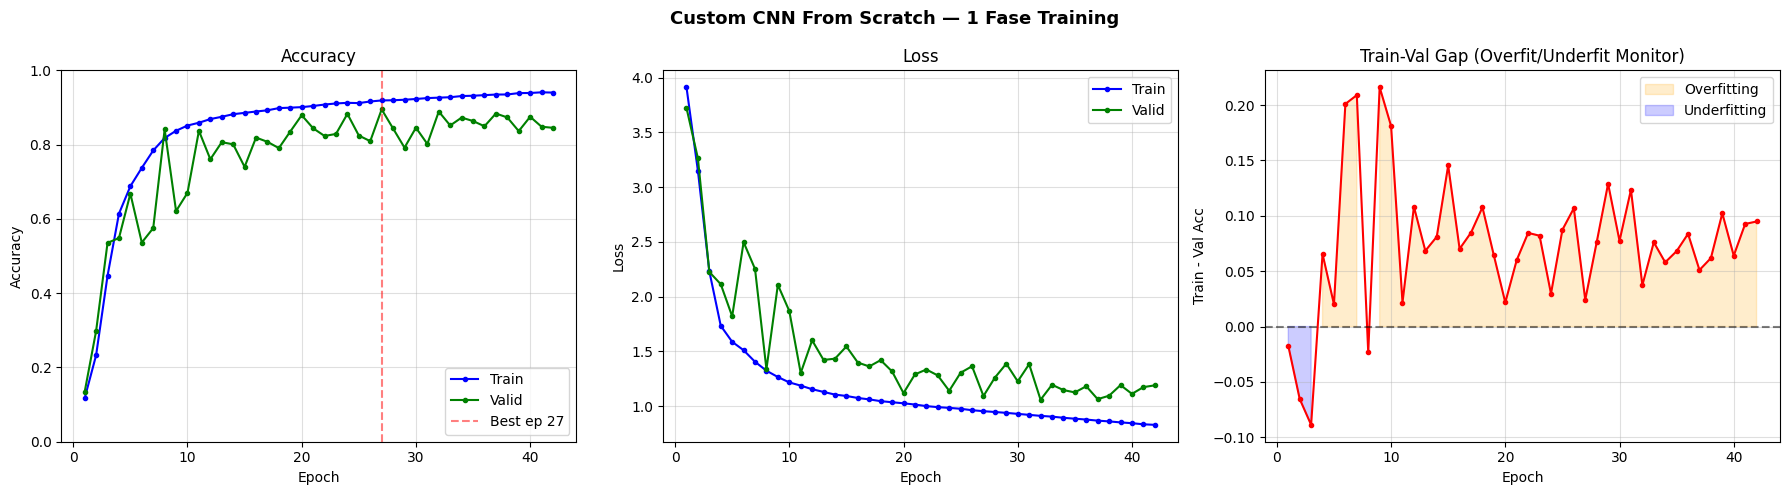

In [12]:
def plot_history(history, title):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    ep       = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    axes[0].plot(ep, acc,     'b-o', ms=3, label='Train')
    axes[0].plot(ep, val_acc, 'g-o', ms=3, label='Valid')
    best_e = int(np.argmax(val_acc)) + 1
    axes[0].axvline(best_e, color='r', linestyle='--', alpha=0.5, label=f'Best ep {best_e}')
    axes[0].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy', ylim=[0,1])
    axes[0].legend(); axes[0].grid(True, alpha=0.4)

    axes[1].plot(ep, loss,     'b-o', ms=3, label='Train')
    axes[1].plot(ep, val_loss, 'g-o', ms=3, label='Valid')
    axes[1].set(title='Loss', xlabel='Epoch', ylabel='Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.4)

    gap = [a - v for a, v in zip(acc, val_acc)]
    axes[2].plot(ep, gap, 'r-o', ms=3)
    axes[2].axhline(0, color='k', linestyle='--', alpha=0.5)
    axes[2].fill_between(ep, gap, 0,
                         where=[g > 0 for g in gap], alpha=0.2, color='orange', label='Overfitting')
    axes[2].fill_between(ep, gap, 0,
                         where=[g < 0 for g in gap], alpha=0.2, color='blue', label='Underfitting')
    axes[2].set(title='Train-Val Gap (Overfit/Underfit Monitor)', xlabel='Epoch', ylabel='Train - Val Acc')
    axes[2].legend(); axes[2].grid(True, alpha=0.4)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history, "Custom CNN From Scratch — 1 Fase Training")


## 11. Evaluasi TEST SET

Evaluasi TEST SET
895/895 [==============================] - 21s 22ms/step

Test Accuracy: 0.8961

                               precision    recall  f1-score   support

           Anggur Busuk Hitam     0.9796    0.9600    0.9697       100
          Anggur Campak Hitam     1.0000    0.9500    0.9744       100
            Anggur Hawar Daun     0.9684    0.9200    0.9436       100
                 Anggur Sehat     0.9796    0.9600    0.9697       100
       Apel Bercak Alternaria     0.9674    0.8900    0.9271       100
          Apel Bercak Cokelat     0.9798    0.9700    0.9749       100
             Apel Busuk Hitam     0.9796    0.9600    0.9697       100
                   Apel Kudis     1.0000    0.9400    0.9691       100
                   Apel Sehat     0.6424    0.9700    0.7729       100
              Blueberry Sehat     0.9109    0.9200    0.9154       100
            Ceri Embun Tepung     0.9896    0.9500    0.9694       100
                   Ceri Sehat     1.0000    1.00

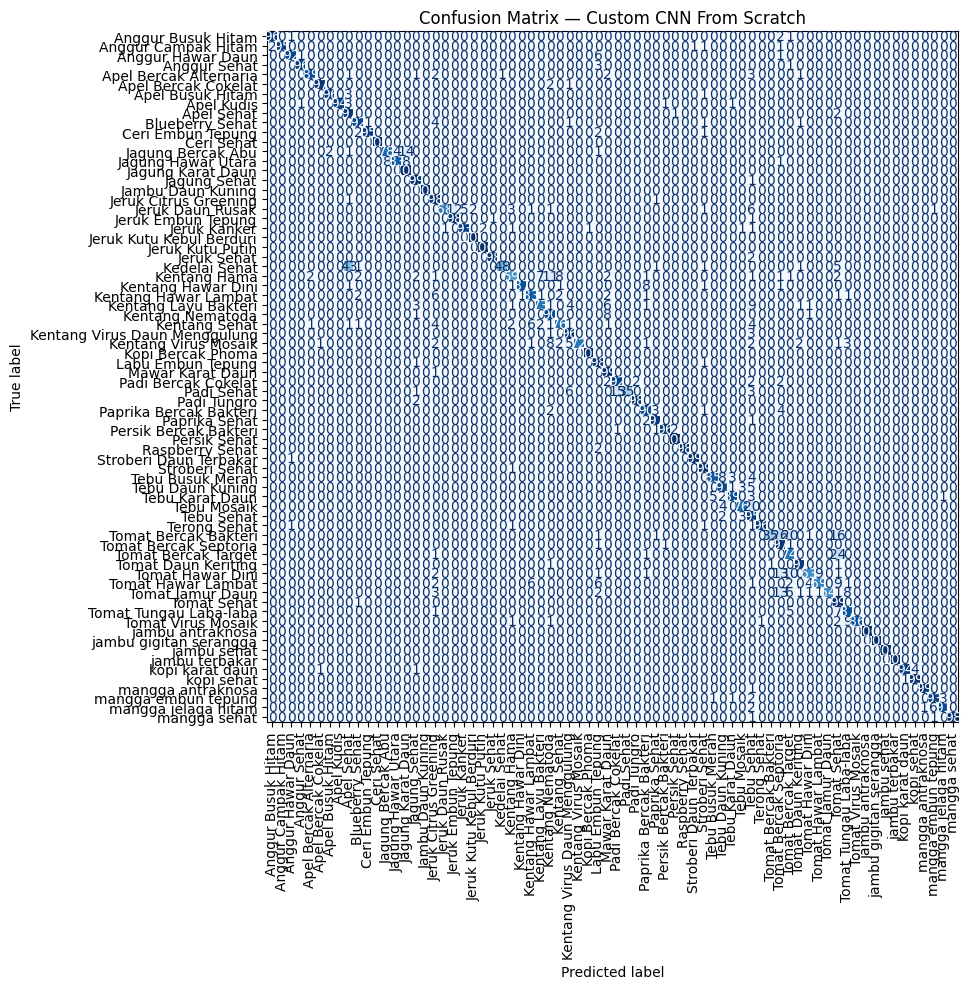

SEMUA HASIL BERHASIL DISIMPAN
Accuracy           : 0.8960893854748604
TXT Report         : C:\Users\crism\Music\New folder (5)\final_output\8\(8) Custom CNN  811\classification_report.txt
CSV Report         : C:\Users\crism\Music\New folder (5)\final_output\8\(8) Custom CNN  811\classification_report.csv
Confusion Matrix   : C:\Users\crism\Music\New folder (5)\final_output\8\(8) Custom CNN  811\confusion_matrix.png
Accuracy TXT       : C:\Users\crism\Music\New folder (5)\final_output\8\(8) Custom CNN  811\test_accuracy.txt


In [13]:
print('=' * 60)
print('Evaluasi TEST SET')
print('=' * 60)

y_pred_probs = model.predict(test_ds, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)

y_true = []
for _, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

acc_test = np.mean(y_true == y_pred)
print(f'\nTest Accuracy: {acc_test:.4f}\n')

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

os.makedirs(SAVE_DIR, exist_ok=True)

txt_path = os.path.join(SAVE_DIR, 'classification_report.txt')
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write('TEST SET - CUSTOM CNN FROM SCRATCH (1 FASE)\n')
    f.write('=' * 60 + '\n\n')
    f.write(f'Accuracy : {acc_test:.4f}\n\n')
    f.write(report)

acc_path = os.path.join(SAVE_DIR, 'test_accuracy.txt')
with open(acc_path, 'w') as f:
    f.write(f'Accuracy = {acc_test:.6f}')

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
csv_path  = os.path.join(SAVE_DIR, 'classification_report.csv')
df_report.to_csv(csv_path)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=90, ax=ax, colorbar=False)
plt.title('Confusion Matrix — Custom CNN From Scratch')
plt.tight_layout()

cm_path = os.path.join(SAVE_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()

print('=' * 60)
print('SEMUA HASIL BERHASIL DISIMPAN')
print('=' * 60)
print('Accuracy           :', acc_test)
print('TXT Report         :', txt_path)
print('CSV Report         :', csv_path)
print('Confusion Matrix   :', cm_path)
print('Accuracy TXT       :', acc_path)


## 12. Visualisasi Sebaran Fitur (t-SNE) — Test Set

Mengekstrak fitur dari layer 'feature_dense'...
895/895 [==============================] - 17s 19ms/step
Feature shape: (7160, 512)
Menjalankan t-SNE (mungkin 2-5 menit)...


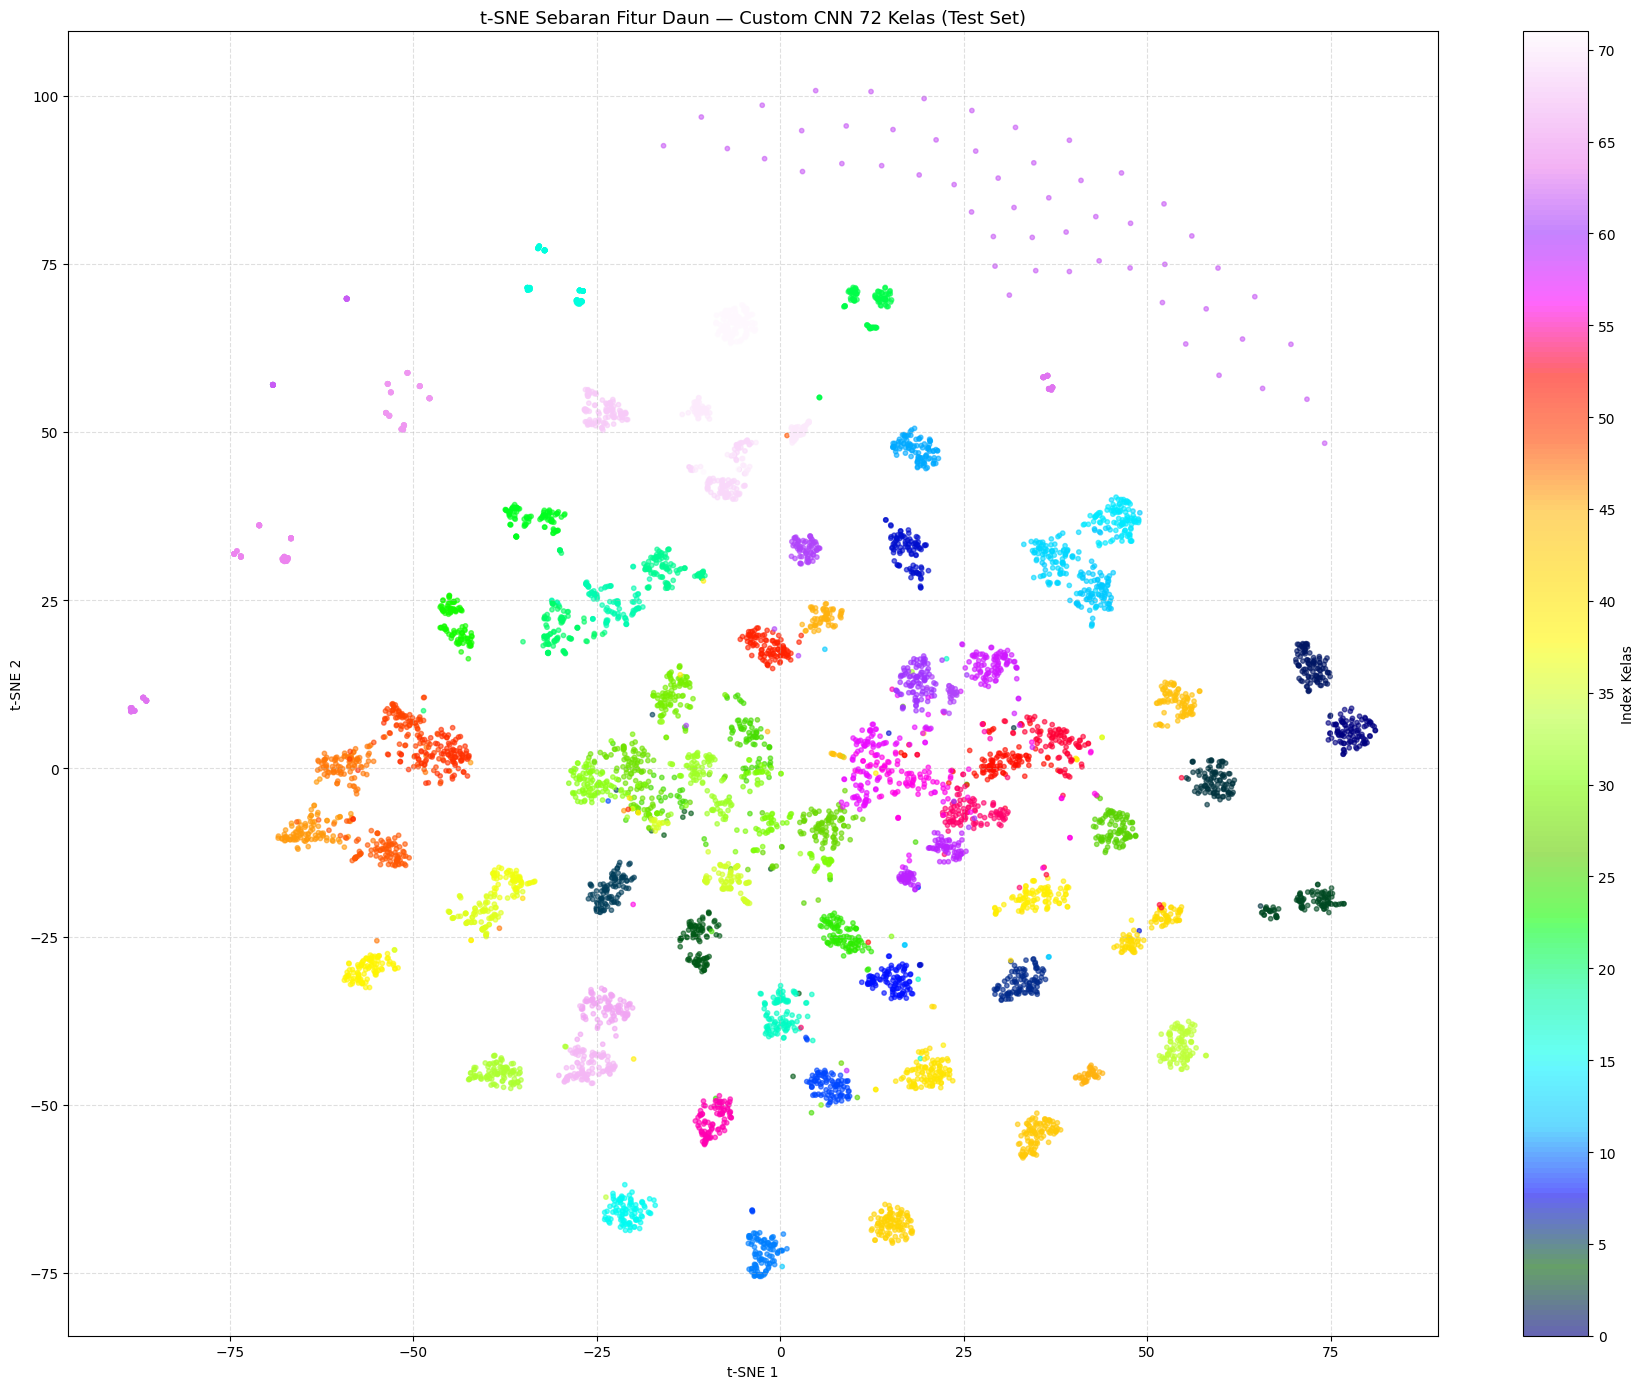

In [14]:
print("Mengekstrak fitur dari layer 'feature_dense'...")
feat_model = models.Model(inputs=model.input,
                          outputs=model.get_layer("feature_dense").output)
feats = feat_model.predict(test_ds)
print(f"Feature shape: {feats.shape}")

print("Menjalankan t-SNE (mungkin 2-5 menit)...")
tsne   = TSNE(n_components=2, random_state=SEED, perplexity=40, max_iter=1000)
X_tsne = tsne.fit_transform(feats)

plt.figure(figsize=(18, 14))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true, cmap='gist_ncar', alpha=0.6, s=10)
cbar = plt.colorbar(sc, label='Index Kelas')
cbar.set_ticks(range(0, len(class_names), 5))
plt.title('t-SNE Sebaran Fitur Daun — Custom CNN 72 Kelas (Test Set)', fontsize=13)
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'tsne_features.png'), dpi=150, bbox_inches='tight')
plt.show()


## 13. Grad-CAM — Helper & Visualisasi
> Layer konvolusi terakhir pada model custom ini diberi nama eksplisit `"last_conv"` saat
> membangun arsitektur, sehingga Grad-CAM tidak perlu menebak nama layer seperti `mixed10` pada InceptionV3.

1/1 [==============================] - 2s 2s/step
Kelas Asli : jambu terbakar
Prediksi   : jambu terbakar (99.6%)


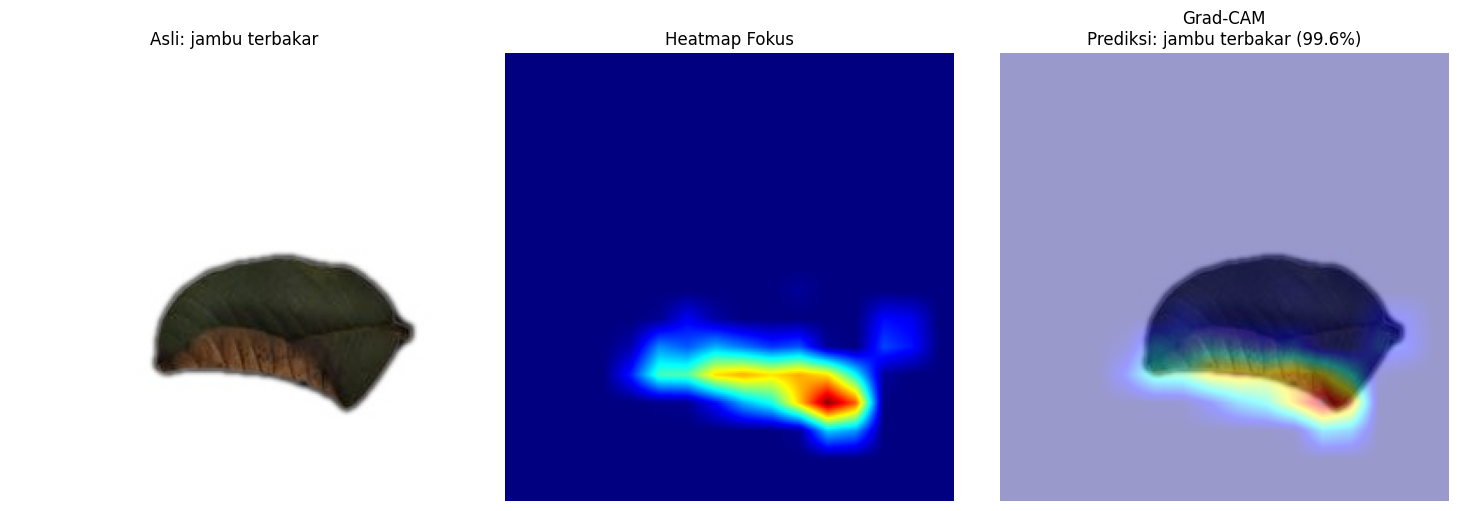

In [15]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="last_conv", pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads        = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    img_orig        = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img_orig        = cv2.resize(img_orig, IMG_SIZE)
    heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    heatmap_color   = cv2.cvtColor(cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    superimposed    = cv2.addWeighted(img_orig, 1 - alpha, heatmap_color, alpha, 0)
    return img_orig, heatmap_color, superimposed

all_images = (glob.glob(os.path.join(TEST_DIR, "*", "*.jpg")) +
              glob.glob(os.path.join(TEST_DIR, "*", "*.jpeg")) +
              glob.glob(os.path.join(TEST_DIR, "*", "*.png")))

if all_images:
    rpath  = random.choice(all_images)
    img_l  = image.load_img(rpath, target_size=IMG_SIZE)
    img_a  = np.expand_dims(image.img_to_array(img_l), 0) / 255.0

    heatmap              = make_gradcam_heatmap(img_a, model, "last_conv")
    orig, heat, blended  = display_gradcam(rpath, heatmap)

    preds      = model.predict(img_a)
    pred_idx   = np.argmax(preds)
    pred_cls   = class_names[pred_idx]
    conf       = preds[0][pred_idx] * 100
    true_cls   = os.path.basename(os.path.dirname(rpath))

    print(f"Kelas Asli : {true_cls}")
    print(f"Prediksi   : {pred_cls} ({conf:.1f}%)")

    plt.figure(figsize=(15, 5))
    plt.subplot(1,3,1); plt.imshow(orig);             plt.title(f"Asli: {true_cls}");                               plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(heat, cmap='jet'); plt.title("Heatmap Fokus");                                   plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(blended);          plt.title(f"Grad-CAM\nPrediksi: {pred_cls} ({conf:.1f}%)"); plt.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'gradcam_sample.png'), dpi=150, bbox_inches='tight')
    plt.show()


## 14. Simpan Model & Label

In [16]:
save_path = os.path.join(SAVE_MODEL, "Leaf_Disease_CustomCNN_Scratch_1Fase.h5")
model.save(save_path)
print(f"✅ Model disimpan : {save_path}")

label_out = os.path.join(SAVE_LABEL, "class_indices.json")
with open(label_out, "w") as f:
    json.dump(class_indices, f, indent=2)
print(f"✅ Label disimpan : {label_out}")
print()
print("Ringkasan output:")
print(f"  Model  : {save_path}")
print(f"  Label  : {label_out}")


✅ Model disimpan : C:\Users\crism\Music\New folder (5)\final_output\8\(8) Custom CNN  811\models\Leaf_Disease_CustomCNN_Scratch_1Fase.h5
✅ Label disimpan : C:\Users\crism\Music\New folder (5)\final_output\8\(8) Custom CNN  811\labels\class_indices.json

Ringkasan output:
  Model  : C:\Users\crism\Music\New folder (5)\final_output\8\(8) Custom CNN  811\models\Leaf_Disease_CustomCNN_Scratch_1Fase.h5
  Label  : C:\Users\crism\Music\New folder (5)\final_output\8\(8) Custom CNN  811\labels\class_indices.json
